# Triangulating Points with Delaunay and Creating Edges

This code demonstrates how to create a graph structure from a set of 2D points using PyTorch Geometric's transforms. The process involves:

1. **Input Data**: We define 4 points roughly in a square shape using torch tensors.

2. **Delaunay Triangulation**: The Delaunay transform creates a triangulation of the points, which maximizes the minimum angle of all triangles in the triangulation.

3. **FaceToEdge Conversion**: The triangles (faces) created by Delaunay are converted to edges, forming a graph structure.

4. **Visualization**: 
    - Blue dots represent the original points
    - Red lines show the edges between points
    - Each point is labeled with its index

The resulting graph shows how points can be connected in a meaningful way based on their spatial relationships. This approach is useful in various applications like mesh generation, computer vision, and spatial data analysis.

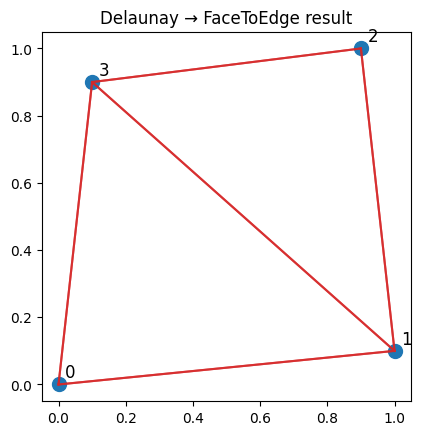

In [2]:
import torch
from torch_geometric.data import Data
from torch_geometric.transforms import Compose, Delaunay, FaceToEdge
import matplotlib.pyplot as plt

# 4 hits roughly in a square (pos is required for Delaunay)
pos = torch.tensor([[0.0, 0.0],
                    [1.0, 0.1],
                    [0.9, 1.0],
                    [0.1, 0.9]])

data = Data(pos=pos)

transform = Compose((Delaunay(), FaceToEdge()))
graph = transform(data)  # Faces from Delaunay; FaceToEdge turns 2-simplices into edges

# Visualize
plt.scatter(pos[:, 0], pos[:, 1], s=100, c='tab:blue')
for i, (x, y) in enumerate(pos):
    plt.text(x + 0.02, y + 0.02, f'{i}', fontsize=12)

edge_index = graph.edge_index
for src, dst in edge_index.t().tolist():
    x0, y0 = pos[src]
    x1, y1 = pos[dst]
    plt.plot([x0, x1], [y0, y1], c='tab:red', linewidth=1.5, alpha=0.8)

plt.gca().set_aspect('equal')
plt.title('Delaunay → FaceToEdge result')
plt.show()


In [6]:
#!/usr/bin/env python3

import os
os.chdir("/exp/sbnd/app/users/yuhw/dl-clus/notebook")

"""
Create a tiny NuGraph-style HDF5 file without relying on pynuml.
Matches the layout that NuGraphData.load expects.
"""
import numpy as np
import h5py
from pathlib import Path

OUTFILE = Path("dummy_nugraph.h5")

def make_event():
    """Return dict[field_name] -> np.ndarray/scalar describing one toy event."""
    num_hits = 5
    num_particles = 2
    num_truth = 2
    num_interactions = 1

    # Node stores -----------------------------------------------------------
    event = {
        "hit/x": np.random.randn(num_hits, 3).astype(np.float32),
        "hit/pos": np.random.randn(num_hits, 3).astype(np.float32),
        "hit/y_semantic": np.random.randint(0, 3, size=num_hits, dtype=np.int64),
        "hit/num_nodes": np.array(num_hits, dtype=np.int64),

        "particle/x": np.random.randn(num_particles, 4).astype(np.float32),
        "particle/num_nodes": np.array(num_particles, dtype=np.int64),

        "particle-truth/x": np.random.randn(num_truth, 4).astype(np.float32),
        "particle-truth/num_nodes": np.array(num_truth, dtype=np.int64),

        "interaction/x": np.random.randn(num_interactions, 6).astype(np.float32),
        "interaction/num_nodes": np.array(num_interactions, dtype=np.int64),
    }

    # Edge stores -----------------------------------------------------------
    hit_to_particle = np.array([[0, 1, 2, 3, 4],
                                [0, 0, 1, 1, 1]], dtype=np.int64)

    event["hit_cluster_particle/edge_index"] = hit_to_particle
    event["hit_cluster-truth_particle-truth/edge_index"] = hit_to_particle.copy()

    event["particle_belongs_to_interaction/edge_index"] = np.array([[0, 1],
                                                                    [0, 0]], dtype=np.int64)

    event["hit_delaunay_hit/edge_index"] = np.array([[0, 1, 2, 3],
                                                     [1, 2, 3, 4]], dtype=np.int64)

    return event

def write_event_dataset(h5file, name, fields):
    """Create /dataset/<name> with the compound layout NuGraph expects."""
    dtype_fields = []
    values = []
    for key, value in fields.items():
        arr = np.asarray(value)
        if arr.ndim == 0:
            dtype_fields.append((key, arr.dtype))
            values.append(arr)
        else:
            dtype_fields.append((key, arr.dtype, arr.shape))
            values.append(arr)
    dtype = np.dtype(dtype_fields)
    h5file.create_dataset(f"dataset/{name}", shape=(), dtype=dtype, data=tuple(values))

def main():
    if OUTFILE.exists():
        OUTFILE.unlink()

    planes = np.array(["u", "v", "y"], dtype="S")
    semantics = np.array(["mip", "hip", "shower"], dtype="S")
    events = ["event_000001"]

    event_fields = make_event()
    datasize = np.array([sum(np.asarray(v).nbytes for v in event_fields.values())],
                        dtype=np.int64)

    with h5py.File(OUTFILE, "w") as f:
        f.create_dataset("planes", data=planes)
        f.create_dataset("semantic_classes", data=semantics)
        f.create_dataset("event_classes", data=np.array(["numu", "nue"], dtype="S"))
        f.create_dataset("gen", data=np.array(1, dtype=np.int32))

        for split in ("train", "validation", "test"):
            f.create_dataset(f"samples/{split}",
                             data=np.array(events, dtype="S"))

        f.create_dataset("datasize/train", data=datasize)

        write_event_dataset(f, events[0], event_fields)

    print(f"Wrote {OUTFILE.resolve()}")

if __name__ == "__main__":
    main()


Wrote /exp/sbnd/app/users/yuhw/dl-clus/notebook/dummy_nugraph.h5
